In [1]:
# 1.
from IPython.display import display,HTML
import pandas as pd

marks = pd.read_csv('https://media-doselect.s3.amazonaws.com/generic/GZVBQG5pzJeNaL1ve50Rv9YNV/class-grades.csv')
print(type(marks))  # <class 'pandas.core.frame.DataFrame'>
'''
To read excel:

marks_xcl = pd.read_excel(...excel file location...)

or

pd.read_excel(..excel file...).to_csv("Test.csv", index = None,header=True)).read_csv()
'''
# Count the number of missing values in each column of the dataset 'marks'.
display(marks.isnull().sum())
#display(marks.isnull().boxplot())
display(marks[:-5])


df = pd.DataFrame(pd.read_csv('https://media-doselect.s3.amazonaws.com/generic/GZVBQG5pzJeNaL1ve50Rv9YNV/class-grades.csv'))
display(df.iloc[0,])  # row-wise
display(df.iloc[:,0]) # column-wise

<class 'pandas.core.frame.DataFrame'>


,0
Prefix,0
Assignment,2
Tutorial,12
Midterm,16
TakeHome,9
Final,5


,Prefix,Assignment,Tutorial,Midterm,TakeHome,Final
0,5,57.14,34.09,64.38,51.48,52.50
1,8,95.05,105.49,67.50,99.07,68.33
2,8,83.70,83.17,30.00,63.15,48.89
3,7,81.22,96.06,49.38,105.93,80.56
4,8,91.32,93.64,95.00,107.41,73.89
...,...,...,...,...,...,...
89,8,97.00,100.52,64.38,90.74,58.61
90,8,NaN,NaN,NaN,NaN,NaN
91,8,96.41,103.71,56.25,95.93,66.39
92,7,95.60,82.28,76.88,108.33,78.33


,0
Prefix,5.00
Assignment,57.14
Tutorial,34.09
Midterm,64.38
TakeHome,51.48
Final,52.50


,Prefix
0,5
1,8
2,8
3,7
4,8
...,...
94,8
95,7
96,8
97,7


In [2]:
# 2. Remove all the rows in the dataset 'marks' having 5 missing values and then print the number of missing values in each column.
import pandas as pd
marks = pd.read_csv('https://media-doselect.s3.amazonaws.com/generic/VodvGKvJAaeNrG7kvOQV38aog/class-grades.csv')

#Type your code here to remove rows with missing value equal to 5
marks = marks[marks.isnull().sum(axis=1)<5]
print(marks.isnull().sum())

Prefix         0
Assignment     0
Tutorial      10
Midterm       14
TakeHome       7
Final          3
dtype: int64


In [3]:
'''3.
The given data frame 'customer' has a column 'Cust_id' which has values Cust_1, Cust_2 and so on.
Remove the repeated 'Cust_' from the column Cust_id so that the output column Cust_id have just numbers like 1, 2, 3 and so on.
Print the first 10 rows of the dataset  'customer' after processing.
'''

import pandas as pd
customer = pd.read_csv('https://media-doselect.s3.amazonaws.com/generic/9B2ZPE1apMvqrLWx7p8ge9dqX/cust_dimen.csv')

customer['Cust_id'] = customer['Cust_id'].apply(lambda x:x[5:])
print(customer.head(10))

        Customer_Name Province   Region Customer_Segment Cust_id
0  MUHAMMED MACINTYRE  NUNAVUT  NUNAVUT   SMALL BUSINESS       1
1        BARRY FRENCH  NUNAVUT  NUNAVUT         CONSUMER       2
2       CLAY ROZENDAL  NUNAVUT  NUNAVUT        CORPORATE       3
3      CARLOS SOLTERO  NUNAVUT  NUNAVUT         CONSUMER       4
4        CARL JACKSON  NUNAVUT  NUNAVUT        CORPORATE       5
5      MONICA FEDERLE  NUNAVUT  NUNAVUT        CORPORATE       6
6     DOROTHY BADDERS  NUNAVUT  NUNAVUT      HOME OFFICE       7
7     NEOLA SCHNEIDER  NUNAVUT  NUNAVUT      HOME OFFICE       8
8         CARLOS DALY  NUNAVUT  NUNAVUT      HOME OFFICE       9
9       CLAUDIA MINER  NUNAVUT  NUNAVUT   SMALL BUSINESS      10


In [4]:
'''
4.
The given Dataframe 'rating' has repeated rows. You need to remove the duplicated rows.

'''
import pandas as pd
rating = pd.read_csv('https://media-doselect.s3.amazonaws.com/generic/JPAqXRWexo7nybkQ7BjPLWVN/rating_final.csv')

display(rating.shape)

updated_rating = rating.drop_duplicates()
display(updated_rating)

updated_rating = rating.drop_duplicates(keep=False)
display(updated_rating)

(1254, 5)

,userID,placeID,rating,food_rating,service_rating
0,U1077,135085,2,2,2
1,U1077,135038,2,2,1
2,U1077,132825,2,2,2
3,U1077,135060,1,2,2
4,U1068,135104,1,1,2
...,...,...,...,...,...
1249,U1043,132630,1,1,1
1250,U1011,132715,1,1,0
1251,U1068,132733,1,1,0
1252,U1068,132594,1,1,1


,userID,placeID,rating,food_rating,service_rating
0,U1077,135085,2,2,2
1,U1077,135038,2,2,1
28,U1044,132583,1,2,1
29,U1070,132608,2,2,1
30,U1070,132609,1,1,1
...,...,...,...,...,...
1249,U1043,132630,1,1,1
1250,U1011,132715,1,1,0
1251,U1068,132733,1,1,0
1252,U1068,132594,1,1,1


211.0 275.0 64.0 115.0 371.0
(1025, 14) (1009, 14)


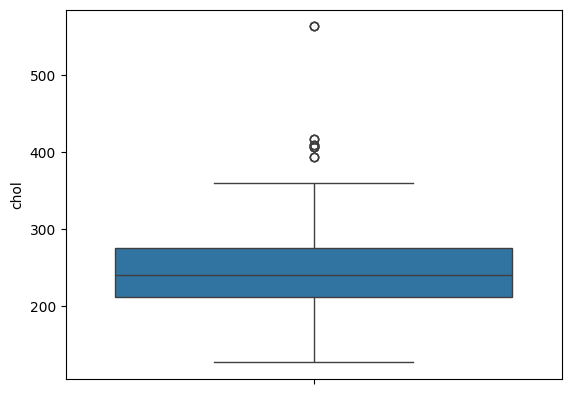

In [5]:
'''
5.
'''
# removing outliers (using IQR)
# https://pythonsansar.com/how-to-remove-outliers-in-python-pandas-package/

import seaborn as sns

heart = pd.read_csv('https://raw.githubusercontent.com/aqwertyuiop48/upgrad_programming/refs/heads/main/2_Course_continuation/_1_Exam_1/1_Statistics_essentials/1_Exploratory_data_analysis/heart.csv')
heart.head(10)

box = sns.boxplot(heart['chol'])

q1 = heart['chol'].quantile(0.25)
q3 = heart['chol'].quantile(0.75)
iqr = q3-q1
lower_limit = q1 - 1.5*iqr
upper_limit = q3 + 1.5*iqr

print(q1,q3,iqr,lower_limit,upper_limit)
little_heart = heart[(heart['chol']>lower_limit) & (heart['chol']<upper_limit)]
little_heart.head(10)
print(heart.shape,little_heart.shape)

float64
float64
[[ 1. nan]
 [nan nan]]
[[1.         0.02667534]
 [0.02667534 1.        ]]


/usr/local/lib/python3.12/dist-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


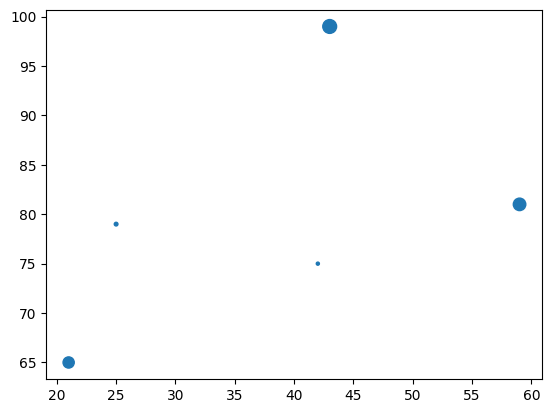

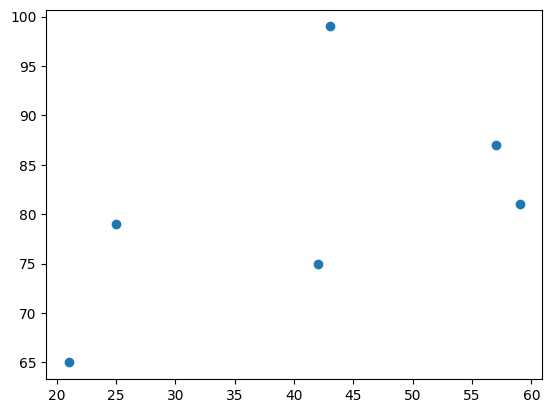

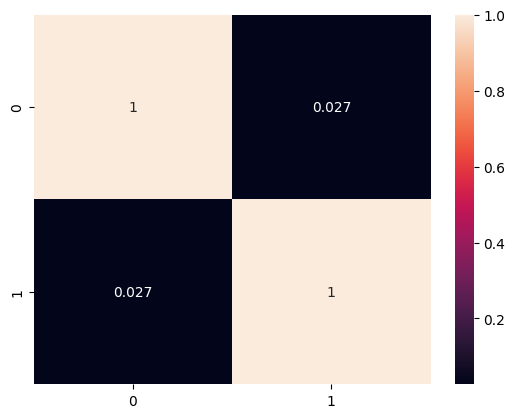

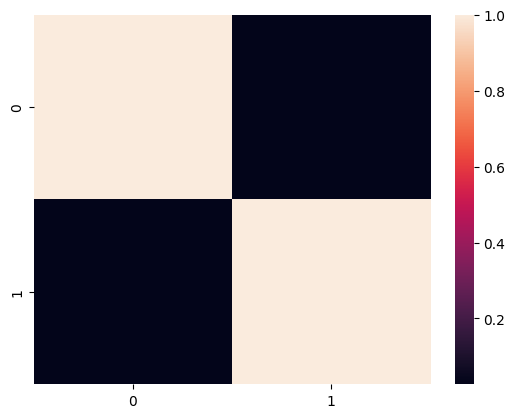

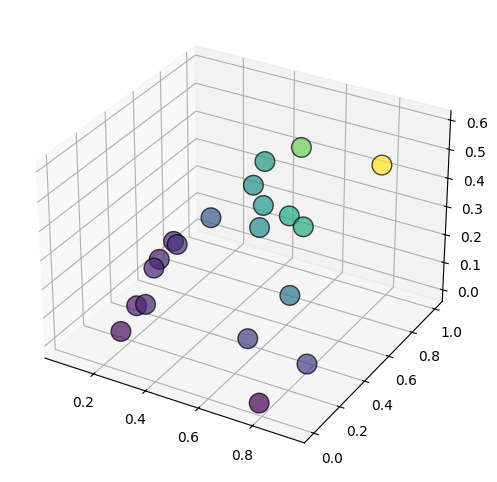

In [6]:
'''
6.
'''
import numpy as np
import matplotlib.pyplot as plt

# correlation matrix
print(marks["Assignment"].dtype)
print(marks["Tutorial"].dtype)
print(np.corrcoef(marks["Assignment"],marks["Tutorial"]))



# x represents the age
x = [43, 21, 25, 42, 57, 59]

# y represents the glucose level
# corresponding to that age
y = [99, 65, 79, 75, 87, 81]
z = [99, 65, 7, 5, -7, 81]

# correlation matrix
matrix = np.corrcoef(x,z)  # max. 2 parameters
print(matrix)
plt.scatter(x,y,z)
plt.show()
plt.scatter(x,y)
plt.show()

plt.show(sns.heatmap(matrix,annot=True))
plt.show(sns.heatmap(matrix,annot=False))

# 3-d correlation

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

x = np.random.rand(20)
y = np.random.rand(20)
z = x*y

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z,
           linewidths=1, alpha=.7,
           edgecolor='k',
           s = 200,
           c=z)
plt.show()

In [7]:
'''
7. The given dataset 'cust_rating' has 3 columns i.e 'rating', ' food_rating', 'service_rating'. Create a new variable 'avg_rating'.

'''

import pandas as pd
cust_rating = pd.read_csv('https://media-doselect.s3.amazonaws.com/generic/GvOkzy5MLdy9zJ8vXMArwpRvN/rating_final.csv')

cust_rating['avg_rating'] = round((cust_rating['rating']+cust_rating['food_rating']+cust_rating['service_rating'])/3,3)

print(cust_rating.head(10))

  userID  placeID  rating  food_rating  service_rating  avg_rating
0  U1077   135085       2            2               2       2.000
1  U1077   135038       2            2               1       1.667
2  U1077   132825       2            2               2       2.000
3  U1077   135060       1            2               2       1.667
4  U1068   135104       1            1               2       1.333
5  U1068   132740       0            0               0       0.000
6  U1068   132663       1            1               1       1.000
7  U1068   132732       0            0               0       0.000
8  U1068   132630       1            1               1       1.000
9  U1067   132584       2            2               2       2.000


In [8]:
'''
8.
The given dataset 'order' has a variable 'Order_Date' with the dates of purchase.
Create a new variable 'day' which will contain the day from the date at variable Order_Date.

'''

import pandas as pd
order = pd.read_csv('https://media-doselect.s3.amazonaws.com/generic/0gjkvLLgNdQLqG10jo5yyJyjK/orders_dimen.csv')
order['Order_Date'] = pd.to_datetime(order['Order_Date'])
order['Day'] = order['Order_Date'].dt.day
display(order.head(10))

/tmp/ipython-input-2614969750.py:10: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  order['Order_Date'] = pd.to_datetime(order['Order_Date'])


,Order_ID,Order_Date,Order_Priority,Ord_id,Day
0,3,2010-10-13,LOW,Ord_1,13
1,293,2012-10-01,HIGH,Ord_2,1
2,483,2011-07-10,HIGH,Ord_3,10
3,515,2010-08-28,NOT SPECIFIED,Ord_4,28
4,613,2011-06-17,HIGH,Ord_5,17
5,643,2011-03-24,HIGH,Ord_6,24
6,678,2010-02-26,LOW,Ord_7,26
7,807,2010-11-23,MEDIUM,Ord_8,23
8,868,2012-06-08,NOT SPECIFIED,Ord_9,8
9,933,2012-08-04,NOT SPECIFIED,Ord_10,4


### Pandas practice Udemy

In [9]:
'''
Important links:
'''
import pandas as pd
import numpy as np
from IPython.display import display , HTML

labels = ['a','b','c']
np_labels = np.array(labels)
print(np.array(labels))

display(HTML('''
<h4>1-d panda series</h4>
'''))
labels = [1,2,3]
np_labels = np.array(labels)
print(pd.Series(data=labels))
print(pd.Series(data=np_labels))
print(pd.Series(data=np_labels,index=labels))

display(HTML('''
<h4>2-d panda series</h4>
'''))
labels = {'a':1,'b':2,'c':3}
print(np.array(labels))
print(pd.Series(data=labels))
print(pd.Series(data=np_labels))
print(pd.Series(data=np_labels,index=labels))

ser1 = pd.Series([1,2,3,4],['Ooty','Kodai','Shimla','Coorg'])
display(ser1 ++--+ ser1.isnull())
display(ser1[::-1][2:])

print(ser1['Ooty'])  # by key
print(ser1[1])  # by index
ser2 = pd.Series([1,2,3,4],['Ooty','Kodai','Shimla','Coorg'])[::-1] # reversing a panda series
#display(ser2)

print(ser1 + ser2)
print(ser1.dtypes)  #int64
ser1 = ser1.astype('float64')
print(ser1.dtypes)  #float64
print(---1**-----ser1[::-1][::-1]**---1**-----1)

df = display(pd.DataFrame(np.random.randn(5,4),['A','B','C','D','E'],['W','X','Y','Z']))
df = pd.DataFrame(np.random.randn(5,4),['A','B','C','D','E'],['W','X','Y','Z'])
print(type(df))  # <class 'pandas.core.frame.DataFrame'>



print(df['X'])  # pass column names as keys
df['new'] = df['X']**2
display(df)

df.drop('new',axis=1,inplace=True) # axis=1 -> column, axis=0 -> row
display(df)

df.drop('E',axis=0,inplace=True) # axis=1 -> column, axis=0 -> row
display(df)

df = df.astype("complex64")
df['new'] = df['X']**df['X']
display(df)

df1 = df
display(df1.iloc[2])
display(df1.loc['C']) # == df1.iloc[2]

# all are working
display(df1>0)
display(df1['W']>0)
display(df1[df1['W']>0])
display(df1[df1['W']>0][['Y','X']])
display(df1[df1['W']>0][['X','Y']])
display(df1[df1[df1['W']>0]>0])
display(df1[df1[df1[df1['W']>0]>0]>0])
display(df1[df1[df1[df1[df1['W']>0]>0]>0]>0])

df1 = df
display(df1[(df1['W']<0) | (df1['X']>2)])
display(df1[(df1['W']<0) & (df1['X']<2)])
display(df1)

df1['states'] = 'CA NY LA WT'.split()
display(df1)

# dataframe index hierarchy

outside = ['G1','G1','G1','G2','G2','G2']
inside = [1,2,3,1,2,3]
hier_index = list(zip(outside,inside))
display(hier_index)
hier_index = pd.MultiIndex.from_tuples(hier_index)
display(hier_index)

# del df
df = pd.DataFrame(np.random.randn(6,2),hier_index,['A','B'])
display(df)

['a' 'b' 'c']


0    1
1    2
2    3
dtype: int64
0    1
1    2
2    3
dtype: int64
1    1
2    2
3    3
dtype: int64


{'a': 1, 'b': 2, 'c': 3}
a    1
b    2
c    3
dtype: int64
0    1
1    2
2    3
dtype: int64
a    1
b    2
c    3
dtype: int64


,0
Ooty,1
Kodai,2
Shimla,3
Coorg,4


,0
Kodai,2
Ooty,1


...

,W,X,Y,Z,new
A,1.081669+0.000000j,0.601147+0.000000j,-0.620914+0.000000j,0.322784+0.000000j,0.736436+0.000000j
B,1.308344+0.000000j,1.048820+0.000000j,0.283948+0.000000j,-0.319472+0.000000j,1.051264+0.000000j
C,-0.499394+0.000000j,-0.290803+0.000000j,-0.753774+0.000000j,-0.595499+0.000000j,0.874915-1.133827j
D,0.444716+0.000000j,-0.127034+0.000000j,1.353491+0.000000j,-0.074355+0.000000j,1.197534-0.505026j


,W,X,Y,Z,new,states
A,1.081669+0.000000j,0.601147+0.000000j,-0.620914+0.000000j,0.322784+0.000000j,0.736436+0.000000j,CA
B,1.308344+0.000000j,1.048820+0.000000j,0.283948+0.000000j,-0.319472+0.000000j,1.051264+0.000000j,NY
C,-0.499394+0.000000j,-0.290803+0.000000j,-0.753774+0.000000j,-0.595499+0.000000j,0.874915-1.133827j,LA
D,0.444716+0.000000j,-0.127034+0.000000j,1.353491+0.000000j,-0.074355+0.000000j,1.197534-0.505026j,WT


[('G1', 1), ('G1', 2), ('G1', 3), ('G2', 1), ('G2', 2), ('G2', 3)]

MultiIndex([('G1', 1),
            ('G1', 2),
            ('G1', 3),
            ('G2', 1),
            ('G2', 2),
            ('G2', 3)],
           )

A         B
G1 1  0.613639 -0.170944
   2  1.594981 -1.125725
   3 -0.472234  1.798076
G2 1 -1.000279  0.046445
   2 -0.419044 -1.847273
   3 -0.998910 -1.065622

In [ ]:
import datetime, pytz;
print("Current Time in IST:", datetime.datetime.now(pytz.utc).astimezone(pytz.timezone('Asia/Kolkata')).strftime('%Y-%m-%d %H:%M:%S'))


Current Time in IST: 2026-02-16 20:24:27


In [ ]:
# --- gcolab wrapper: list files in outputs/ ---
import os, datetime
_out_dir = 'outputs'
os.makedirs(_out_dir, exist_ok=True)
print(f"Files in {_out_dir}:")
_files = []
for _fn in os.listdir(_out_dir):
    _fp = os.path.join(_out_dir, _fn)
    if os.path.isfile(_fp):
        _st = os.stat(_fp)
        _files.append((datetime.datetime.fromtimestamp(_st.st_mtime).strftime('%Y-%m-%d %H:%M:%S'), _st.st_size, _fn))
_files.sort()
for _m, _s, _n in _files:
    if _s < 1024:
        _h = f"{_s} B"
    elif _s < 1024*1024:
        _h = f"{_s/1024:.2f} KB"
    else:
        _h = f"{_s/(1024*1024):.2f} MB"
    print(f"{_m}  {_h:>10}  {_n}")


In [ ]:
# --- gcolab wrapper: zip outputs/ -> outputs.zip ---
import os, shutil
os.makedirs('outputs', exist_ok=True)
shutil.make_archive('outputs', 'zip', 'outputs')
print('Created outputs.zip')
